Installing SOTA libraries (this may take a minute)...
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.1 which is incompatible.
Loading Models on cpu...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/620M [00:00<?, ?B/s]

Grounded-SAM Pipeline Ready.

UPLOAD STEP: Please upload your image now.


Saving egg.jpg to egg.jpg
Scanning egg.jpg with Grounded-SAM...
Stage 1 (Detection): Found 1 candidate regions.


/tmp/ipykernel_10083/33660945.py:152: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet_mapper = cm.get_cmap('jet')


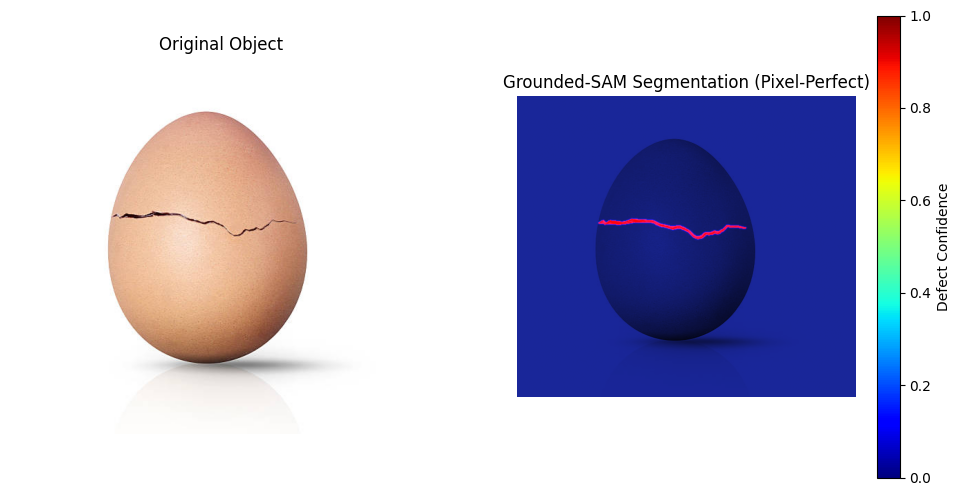

In [1]:
# --- 1. Install & Setup (SOTA Stack) ---
# We need the Segment Anything Model (SAM) from Meta
print("Installing SOTA libraries (this may take a minute)...")
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q transformers==4.38.1 accelerate bitsandbytes scipy torch numpy matplotlib

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from transformers import Owlv2Processor, Owlv2ForObjectDetection
from segment_anything import sam_model_registry, SamPredictor
import sys
import os
from google.colab import files  # Explicit import for uploading

# Download SAM Checkpoint (ViT-Base is fast and accurate enough)
if not os.path.exists("sam_vit_b_01ec64.pth"):
    print("Downloading SAM checkpoint...")
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

# --- 2. Initialize Models ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading Models on {device}...")

# A. Detector: OWL-ViT v2 (The "Eyes")
detector_id = "google/owlv2-base-patch16-ensemble"
processor = Owlv2Processor.from_pretrained(detector_id, do_pad=False)
detector = Owlv2ForObjectDetection.from_pretrained(detector_id).to(device)

# B. Segmenter: SAM (The "Hands")
sam_checkpoint = "sam_vit_b_01ec64.pth"
model_type = "vit_b"
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)
predictor = SamPredictor(sam)

print("Grounded-SAM Pipeline Ready.")

# --- 3. The Precision Pipeline ---
class GroundedSAMAnomalyDetector:
    def __init__(self):
        # Universal Defect Dictionary
        self.defects = [
            "crack", "fracture", "fissure", "broken piece", "split", "gap", "hole",
            "scratch", "dent", "chip", "rotten spot", "mold", "discoloration",
            "dark line", "broken shell"
        ]

    def scan(self, image_path, sensitivity=0.1):
        try:
            image_pil = Image.open(image_path).convert("RGB")
            image_np = np.array(image_pil)
        except:
            return None, None

        # Step 1: Detect Boxes (OWL-ViT)
        inputs = processor(text=[self.defects], images=image_pil, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = detector(**inputs)

        target_sizes = torch.Tensor([image_pil.size[::-1]]).to(device)
        results = processor.post_process_object_detection(
            outputs=outputs, target_sizes=target_sizes, threshold=sensitivity
        )[0]

        boxes = results["boxes"].cpu().numpy()
        scores = results["scores"].cpu().numpy()

        print(f"Stage 1 (Detection): Found {len(boxes)} candidate regions.")

        if len(boxes) == 0:
            return image_pil, np.zeros((image_pil.height, image_pil.width))

        # Step 2: Segment Pixels (SAM)
        # We assume the box is accurate and ask SAM to segment the object INSIDE it.
        predictor.set_image(image_np)

        # Transform boxes for SAM
        transformed_boxes = predictor.transform.apply_boxes_torch(
            torch.tensor(boxes, device=device), image_np.shape[:2]
        )

        # SAM Inference (Batch processing all boxes)
        masks, _, _ = predictor.predict_torch(
            point_coords=None,
            point_labels=None,
            boxes=transformed_boxes,
            multimask_output=False,
        )

        # Step 3: Aggregation
        # Combine all binary masks into one heatmap
        final_mask = np.zeros((image_pil.height, image_pil.width), dtype=float)

        for i, mask in enumerate(masks):
            # mask is [1, H, W] bool
            binary_mask = mask[0].cpu().numpy().astype(float)

            # Weight the mask by the detection score
            # We add them up so overlapping cracks get hotter
            final_mask += binary_mask * scores[i]

        # Normalize
        if np.max(final_mask) > 0:
            final_mask = final_mask / np.max(final_mask)

        return image_pil, final_mask

# --- 4. Interactive Upload & Execution ---
pipeline = GroundedSAMAnomalyDetector()

print("\n" + "="*40)
print("UPLOAD STEP: Please upload your image now.")
print("="*40)
uploaded = files.upload()

if not uploaded:
    print("No file uploaded.")
else:
    # Get the first uploaded filename
    image_path = list(uploaded.keys())[0]
    print(f"Scanning {image_path} with Grounded-SAM...")

    img, heatmap = pipeline.scan(image_path)

    # --- 5. "Electric" Visualization (Pixel-Perfect) ---
    if img is not None:
        plt.figure(figsize=(12, 6))

        # A. Original
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Original Object")

        # B. Electric Composite
        plt.subplot(1, 2, 2)

        # 1. Dark Blue Base
        img_np = np.array(img).astype(float) / 255.0
        grayscale = np.mean(img_np, axis=2)
        base_layer = np.stack([
            grayscale * 0.1,  # Red
            grayscale * 0.15, # Green
            grayscale * 0.6   # Blue (Deep Industrial Blue)
        ], axis=2)

        # 2. Electric Glow
        # Because 'heatmap' is now a jagged mask, the glow will be jagged too.
        jet_mapper = cm.get_cmap('jet')
        glow_rgb = jet_mapper(heatmap)[:, :, :3]

        # 3. Intensity & Sharpness
        # Just a tiny blur to make it "glow" rather than look like a sticker.
        from scipy.ndimage import gaussian_filter
        glow_mask = gaussian_filter(heatmap, sigma=1.0)

        # Additive Blending
        intensity = np.expand_dims(glow_mask, axis=2)

        # Composite: Base + (Color * Intensity * Brightness)
        composite_img = base_layer + (glow_rgb * intensity * 3.5)
        composite_img = np.clip(composite_img, 0.0, 1.0)

        plt.imshow(composite_img)
        plt.axis('off')
        plt.title("Grounded-SAM Segmentation (Pixel-Perfect)")

        cbar = plt.colorbar(cm.ScalarMappable(cmap='jet'), ax=plt.gca())
        cbar.set_label("Defect Confidence")

        plt.show()